# Clustering Jerarquico — Gimnasio con 4 variables y radar chart

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · No Supervisado · Clustering · Jerárquico

---

**Objetivo:** Segmentacion completa de socios del gimnasio usando 4 variables operativas, con radar chart por segmento y recomendaciones accionables por cluster.

**Contexto de negocio:** La cadena necesita perfiles de cliente accionables — no solo saber que hay grupos, sino que hacer con cada uno. Este notebook genera "fichas de persona" basadas en datos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
np.random.seed(42)

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'   # único color de énfasis / serie única en scatter y líneas (1 por gráfico)
PURPLE_LIGHT  = '#9b9cff'   # EDA de una sola serie (histogramas independientes)
POSITIVE      = '#6b8158'   # exclusivo signo positivo
NEGATIVE      = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR   = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE  = '#8f8c9e'   # líneas de contexto
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ líneas de contexto
INK           = '#111111'
MUTED         = '#707070'

# Paleta categórica para identidad de cluster — validada (ΔE OKLab, simulación CVD) para
# pares adyacentes (barras, líneas, enlaces de dendrograma). En scatter/PCA con 4+ clusters
# el color por sí solo no basta para daltonismo severo: por eso cada cluster lleva también
# una forma de marcador distinta (CLUSTER_MARKERS) — nunca dependas solo del color.
CLUSTER_PALETTE = ['#7a7bff', '#eb6834', '#1baf7a', '#e34948', '#eda100', '#e87ba4', '#008300']
CLUSTER_MARKERS = ['o', 's', '^', 'D', 'v', 'P', 'X']

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

print("Librerias cargadas correctamente")

## 1. Carga y seleccion de variables

Usamos las 4 variables operativas: Antiguedad, Asistencias, Horas Pico y Gasto Extra. Excluimos Satisfecho y Abandono porque son targets de otros analisis, no features de comportamiento.

In [2]:
df = pd.read_excel("gym_clientes.xlsx")

FEATURES = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]
LABELS = ["Antiguedad", "Asistencias", "Horas Pico", "Gasto Extra"]

print(f"Dataset: {df.shape[0]} clientes, {df.shape[1]} variables totales")
print(f"Variables seleccionadas para clustering: {FEATURES}")
print(f"\nEstadisticas:")
display(df[FEATURES].describe().round(2))

Dataset: 300 clientes, 7 variables totales
Variables seleccionadas para clustering: ['Antiguedad_Meses', 'Asistencias_Mes', 'Horas_Pico_Mes', 'Gasto_Mensual_Extra']

Estadisticas:


,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra
count,300.00,300.00,300.00,300.00
mean,18.88,12.16,14.67,81.69
std,10.60,7.27,6.09,30.47
min,1.00,0.00,1.41,10.00
25%,9.00,6.00,9.65,61.25
50%,20.00,12.00,15.07,82.24
75%,28.00,18.25,19.75,104.11
max,35.00,24.00,24.00,145.91


## 2. Exploracion: distribuciones y correlaciones

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

# Distribuciones
for i, (feat, label) in enumerate(zip(FEATURES, LABELS)):
    axes[i].hist(df[feat], bins=25, color=PURPLE_LIGHT, edgecolor="white", alpha=0.8)
    axes[i].set_title(label, fontsize=11)
    axes[i].set_ylabel("Frecuencia")

# Scatter principales
axes[4].scatter(df["Antiguedad_Meses"], df["Gasto_Mensual_Extra"], color=PURPLE, alpha=0.4, s=20, edgecolors="k", linewidths=0.2)
axes[4].set_xlabel("Antiguedad")
axes[4].set_ylabel("Gasto Extra")
axes[4].set_title("Antiguedad vs Gasto")

# Correlacion
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0, ax=axes[5], square=True, linewidths=0.5)
color_annotations(axes[5], corr.values, threshold=0.8)
axes[5].set_title("Correlacion")

plt.tight_layout()
plt.show()

## 3. Estandarizacion

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])

print("Escalas originales vs estandarizadas:")
for i, feat in enumerate(FEATURES):
    orig = df[feat]
    print(f"  {feat:25s} — orig: [{orig.min():.0f}, {orig.max():.0f}], "
          f"escalado: [{X_scaled[:, i].min():.2f}, {X_scaled[:, i].max():.2f}]")

Escalas originales vs estandarizadas:
  Antiguedad_Meses          — orig: [1, 35], escalado: [-1.69, 1.52]
  Asistencias_Mes           — orig: [0, 24], escalado: [-1.68, 1.63]
  Horas_Pico_Mes            — orig: [1, 24], escalado: [-2.18, 1.53]
  Gasto_Mensual_Extra       — orig: [10, 146], escalado: [-2.36, 2.11]


## 4. Dendrograma y seleccion de k

In [ ]:
Z = linkage(X_scaled, method="ward", metric="euclidean")

from scipy.cluster.hierarchy import set_link_color_palette
set_link_color_palette(CLUSTER_PALETTE)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrograma
dendrogram(Z, ax=axes[0], truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=8, above_threshold_color=INK)
axes[0].set_title("Dendrograma (Ward)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Clientes")
axes[0].set_ylabel("Distancia")

# Silhouette por k
scores = []
for k in range(2, 8):
    labels_k = fcluster(Z, t=k, criterion="maxclust")
    sil = silhouette_score(X_scaled, labels_k)
    scores.append({"k": k, "silhouette": round(sil, 4)})

df_scores = pd.DataFrame(scores)
axes[1].plot(df_scores["k"], df_scores["silhouette"], marker="o", linewidth=2, color=PURPLE)
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score por k", fontsize=13, fontweight="bold")
axes[1].set_xticks(range(2, 8))
best_k = df_scores.loc[df_scores["silhouette"].idxmax(), "k"]
axes[1].axvline(x=best_k, color=INK, linestyle="--", alpha=0.6, label=f"Mejor: k={best_k}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mejor k: {best_k} (silhouette={df_scores['silhouette'].max():.4f})")

## 5. Asignacion de clusters y scatter 2D

In [ ]:
df["Cluster"] = fcluster(Z, t=int(best_k), criterion="maxclust")

# PCA rapido para visualizar en 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for i, cl in enumerate(sorted(df["Cluster"].unique())):
    mask = df["Cluster"] == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.6, color=CLUSTER_PALETTE[i], marker=CLUSTER_MARKERS[i],
               label=f"Cluster {cl} (n={mask.sum()})", edgecolors="k", linewidths=0.3)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.set_title("Clusters proyectados en 2 componentes principales")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Varianza explicada por 2 PCs: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 6. Perfil de cada segmento

In [7]:
perfil = df.groupby("Cluster").agg(
    n=("ID_Cliente", "count"),
    antiguedad=("Antiguedad_Meses", "mean"),
    asistencias=("Asistencias_Mes", "mean"),
    horas_pico=("Horas_Pico_Mes", "mean"),
    gasto=("Gasto_Mensual_Extra", "mean"),
    abandono_pct=("Abandono", lambda x: (x.mean()*100)),
    satisfecho_pct=("Satisfecho", lambda x: (x.mean()*100))
).round(1)

print("Perfil medio por segmento:")
display(perfil)

Perfil medio por segmento:


,n,antiguedad,asistencias,horas_pico,gasto,abandono_pct,satisfecho_pct
Cluster,,,,,,,
1,124,17.4,19.3,20.6,106.5,0.0,91.1
2,176,19.9,7.1,10.5,64.2,27.8,17.6


## 7. Radar chart por segmento

El radar chart permite comparar visualmente el perfil de cada cluster en todas las dimensiones a la vez — herramienta imprescindible para presentar segmentos a stakeholders no tecnicos.

In [ ]:
# Normalizar perfiles para radar (0-1)
perfil_norm = df.groupby("Cluster")[FEATURES].mean()
for col in FEATURES:
    perfil_norm[col] = (perfil_norm[col] - df[col].min()) / (df[col].max() - df[col].min())

n_clusters = len(perfil_norm)
angles = np.linspace(0, 2 * np.pi, len(FEATURES), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colores = CLUSTER_PALETTE

for i, cl in enumerate(sorted(perfil_norm.index)):
    values = perfil_norm.loc[cl].values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f"Cluster {cl}", color=colores[i % len(colores)])
    ax.fill(angles, values, alpha=0.1, color=colores[i % len(colores)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(LABELS, fontsize=11)
ax.set_title("Perfil de cada segmento", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## 8. Boxplots comparativos

/sessions/zen-stoic-carson/tmp/ipykernel_4/352337316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y=feat, ax=axes[i], palette="Set2")
/sessions/zen-stoic-carson/tmp/ipykernel_4/352337316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y=feat, ax=axes[i], palette="Set2")
/sessions/zen-stoic-carson/tmp/ipykernel_4/352337316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y=feat, ax=axes[i], palette="Set2")


/sessions/zen-stoic-carson/tmp/ipykernel_4/352337316.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cluster", y=feat, ax=axes[i], palette="Set2")


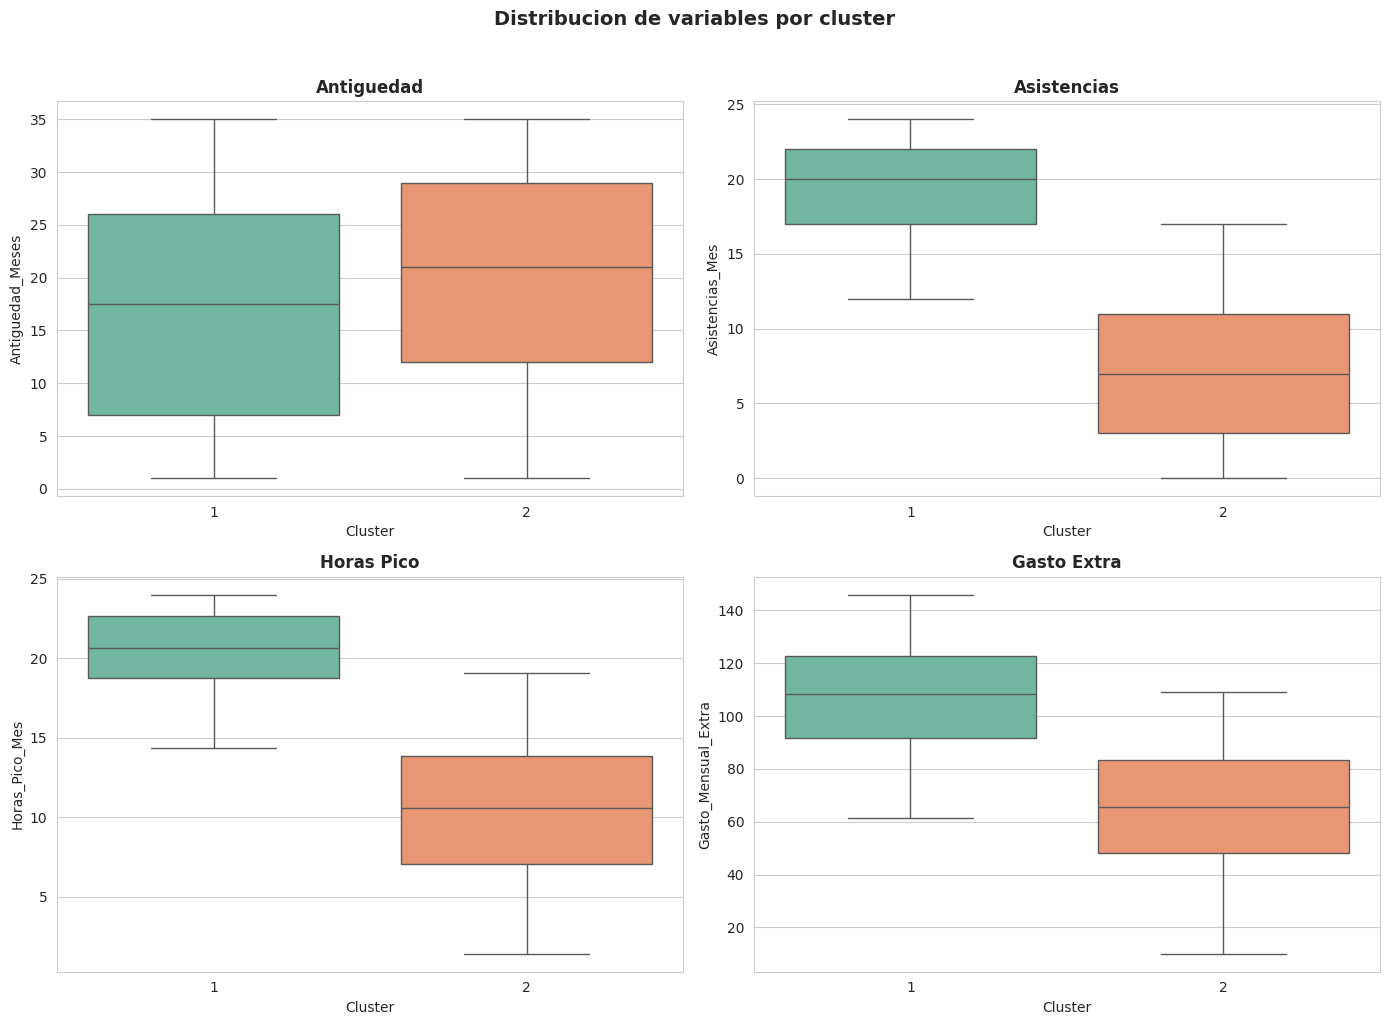

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (feat, label) in enumerate(zip(FEATURES, LABELS)):
    sns.boxplot(data=df, x="Cluster", y=feat, ax=axes[i], palette=CLUSTER_PALETTE)
    axes[i].set_title(label, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Cluster")

plt.suptitle("Distribucion de variables por cluster", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 9. Conclusiones y recomendaciones

**Hallazgos:**
- Con 4 variables operativas, el clustering genera segmentos con perfiles claramente diferenciados.
- El radar chart permite comunicar perfiles complejos de forma intuitiva.
- Cruzar clusters con abandono/satisfaccion (variables no usadas en el clustering) valida que los segmentos tienen sentido de negocio.

**Recomendaciones por segmento:**
- Los perfiles de alto gasto y alta asistencia son candidatos a programas de fidelizacion premium.
- Los perfiles de baja asistencia y bajo gasto necesitan campanas de reactivacion antes de que abandonen.
- Los segmentos con alto % de abandono requieren intervencion prioritaria.

**Diferencia con el notebook de 2 variables:** Con 4 features, los segmentos capturan mas matices del comportamiento del socio. El radar chart muestra que cada cluster tiene un "shape" unico — no solo una posicion en un plano.